# Filter-Based Dimensionality Reduction

## Objective
To apply filter-based dimensionality reduction techniques 
independent of classifier performance and evaluate their 
impact on classification accuracy.

Methods:
- Correlation-based feature selection
- PCA
- LDA
- SVD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv(r"C:\ML PROJECT\Dimensionality-Reduction-Classification-Study\data\raw_data\breast_cancer.csv")

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Correlation-Based Feature Selection

In [3]:
corr_matrix = X_train.corr().abs()

In [4]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X_train_corr = X_train.drop(columns=to_drop)
X_test_corr = X_test.drop(columns=to_drop)

In [5]:
X_train_corr = scaler.fit_transform(X_train_corr)
X_test_corr = scaler.transform(X_test_corr)

### Principal Component Analysis

In [6]:
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

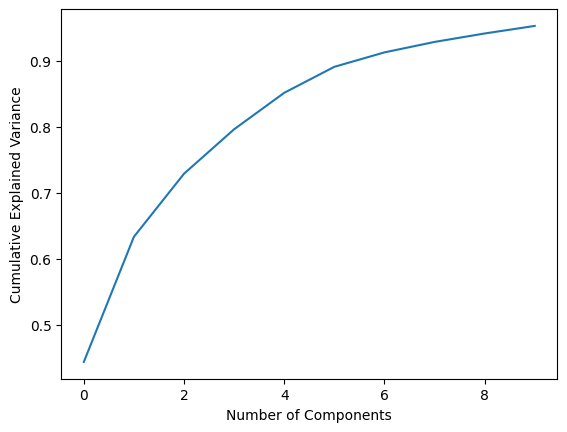

In [7]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

### LDA

In [8]:
lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

### SVD

In [9]:
svd = TruncatedSVD(n_components=10)

X_train_svd = svd.fit_transform(X_train_scaled)
X_test_svd = svd.transform(X_test_scaled)

In [10]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

In [11]:
def evaluate_models(X_train, X_test, y_train, y_test, method_name):
    results = []
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        results.append({
            "Method": method_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })
    
    return pd.DataFrame(results)

In [12]:
results_corr = evaluate_models(X_train_corr, X_test_corr, y_train, y_test, "Correlation")
results_pca = evaluate_models(X_train_pca, X_test_pca, y_train, y_test, "PCA")
results_lda = evaluate_models(X_train_lda, X_test_lda, y_train, y_test, "LDA")
results_svd = evaluate_models(X_train_svd, X_test_svd, y_train, y_test, "SVD")

In [13]:
filter_results = pd.concat([
    results_corr,
    results_pca,
    results_lda,
    results_svd
])

filter_results

,Method,Model,Accuracy,Precision,F1 Score,ROC-AUC
0,Correlation,Random Forest,0.947368,0.945946,0.958904,0.992394
1,Correlation,Decision Tree,0.912281,0.918919,0.931507,0.900794
2,Correlation,SVM,0.964912,0.985714,0.971831,0.995701
3,Correlation,Naive Bayes,0.885965,0.927536,0.907801,0.953373
4,Correlation,KNN,0.964912,0.972222,0.972222,0.995040
0,PCA,Random Forest,0.921053,0.943662,0.937063,0.984954
1,PCA,Decision Tree,0.912281,0.930556,0.930556,0.905754
2,PCA,SVM,0.973684,0.985915,0.979021,0.995040
3,PCA,Naive Bayes,0.921053,0.931507,0.937931,0.970899
4,PCA,KNN,0.956140,0.958904,0.965517,0.978836


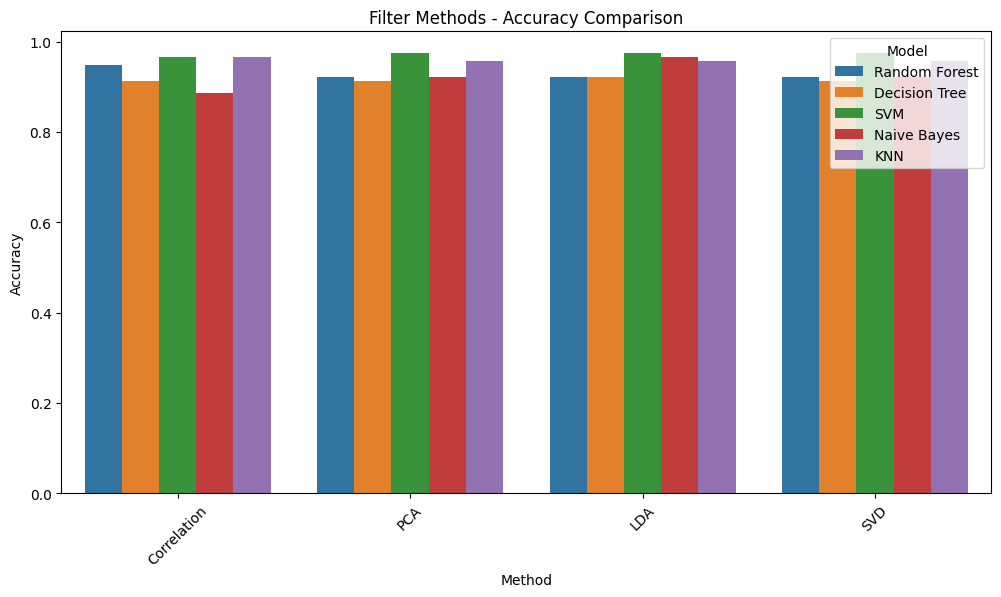

In [14]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=filter_results, x="Method", y="Accuracy", hue="Model")
plt.title("Filter Methods - Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

In [15]:
filter_results.to_csv(r"C:\ML PROJECT\Dimensionality-Reduction-Classification-Study\results\filter_results.csv", index=False)